In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/Cardiotocographic.csv")
# Display basic information about the dataset
df.info(), df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


(None,
            LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
 0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
 1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
 2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
 3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
 4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   
 
    MLTV  Width  Tendency  NSP  
 0   2.4   64.0  0.999926  2.0  
 1  10.4  130.0  0.000000  1.0  
 2  13.4  130.0  0.000000  1.0  
 3  23.0  117.0  1.000000  1.0  
 4  19.9  117.0  1.000000  1.0  )

In [ ]:
#Initial Observations:
#Dataset Size: 2,126 rows and 14 columns.
#Data Types:
#All columns are numerical (float64), meaning no categorical variables exist

In [7]:
# Checking missing values in each column
missing_values = df.isnull().sum()

# Statistical summary of numerical variables
stats_summary = df.describe()

missing_values, stats_summary


(LB          21
 AC          20
 FM           0
 UC           0
 DL           0
 DS          21
 DP          21
 ASTV         0
 MSTV         0
 ALTV         0
 MLTV        21
 Width       21
 Tendency    21
 NSP         21
 dtype: int64,
                 LB           AC           FM           UC           DL  \
 count  2105.000000  2106.000000  2126.000000  2126.000000  2126.000000   
 mean    133.343598     0.003219     0.009894     0.004391     0.001895   
 std      11.270154     0.004391     0.067540     0.003340     0.003343   
 min      51.842487    -0.019284    -0.480634    -0.014925    -0.015393   
 25%     126.000000     0.000000     0.000000     0.001851     0.000000   
 50%     133.000000     0.001634     0.000000     0.004484     0.000000   
 75%     140.000000     0.005650     0.002567     0.006536     0.003289   
 max     214.000000     0.038567     0.961268     0.030002     0.030769   
 
                 DS           DP         ASTV         MSTV         ALTV  \
 count  2

In [ ]:
#Missing Values:
#Some columns have missing values, including LB, AC, DS, DP, MLTV, Width, Tendency, and NSP.

In [8]:
# Imputing missing values using median (to avoid impact of outliers)
for col in df.columns:
    df[col].fillna(df[col].median(), inplace=True)

# Verify if all missing values are handled
df.isnull().sum()


<ipython-input-8-3ae40b5a9ce2>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
LB,0
AC,0
FM,0
UC,0
DL,0
DS,0
DP,0
ASTV,0
MSTV,0
ALTV,0


In [9]:
# Identifying columns with negative values
negative_values = df[df < 0].sum()

# Replacing negative values with their absolute values (assuming measurement errors)
df[df < 0] = df.abs()

# Verify if negative values are corrected
corrected_negative_values = df[df < 0].sum()

negative_values, corrected_negative_values


(LB            0.000000
 AC           -0.078900
 FM           -2.935539
 UC           -0.060213
 DL           -0.093590
 DS           -0.009565
 DP           -0.022137
 ASTV       -315.000000
 MSTV        -19.800000
 ALTV       -286.052526
 MLTV       -254.373783
 Width      -870.000000
 Tendency   -181.252074
 NSP          -6.025988
 dtype: float64,
 LB          0.0
 AC          0.0
 FM          0.0
 UC          0.0
 DL          0.0
 DS          0.0
 DP          0.0
 ASTV        0.0
 MSTV        0.0
 ALTV        0.0
 MLTV        0.0
 Width       0.0
 Tendency    0.0
 NSP         0.0
 dtype: float64)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


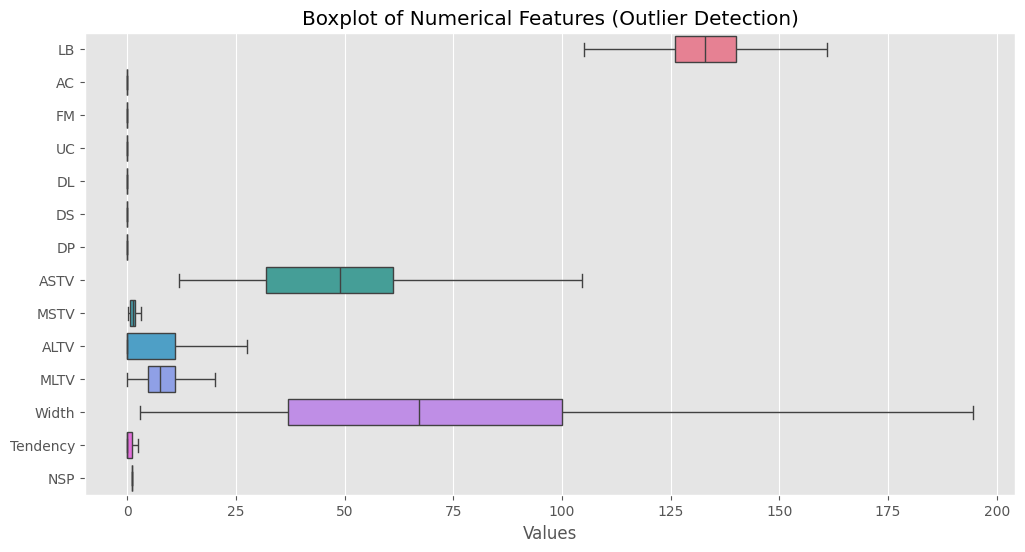

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
# Get available plot styles (not calling it)
available_styles = plt.style.available
print(available_styles)
# Print or inspect the list of available styles
# Set plot style (choose one from the list)
# For instance, 'ggplot'
plt.style.use('ggplot')
# Boxplots for outlier detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot of Numerical Features (Outlier Detection)")
plt.xlabel("Values")
plt.show()




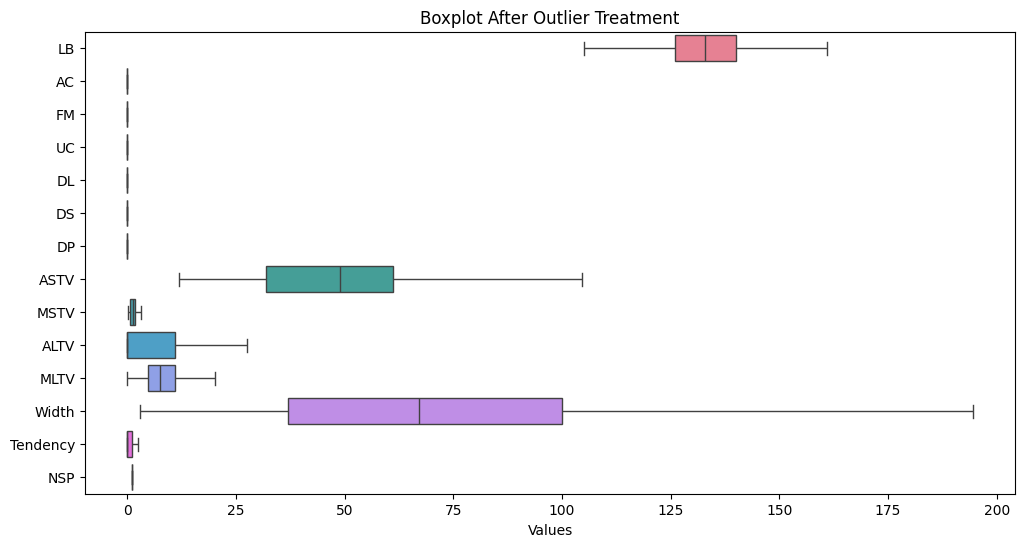

In [18]:
# Using IQR method to handle outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers to upper and lower bounds
df = df.clip(lower=lower_bound, upper=upper_bound, axis=1)

# Re-plot boxplots after outlier treatment
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, orient="h")
plt.title("Boxplot After Outlier Treatment")
plt.xlabel("Values")
plt.show()


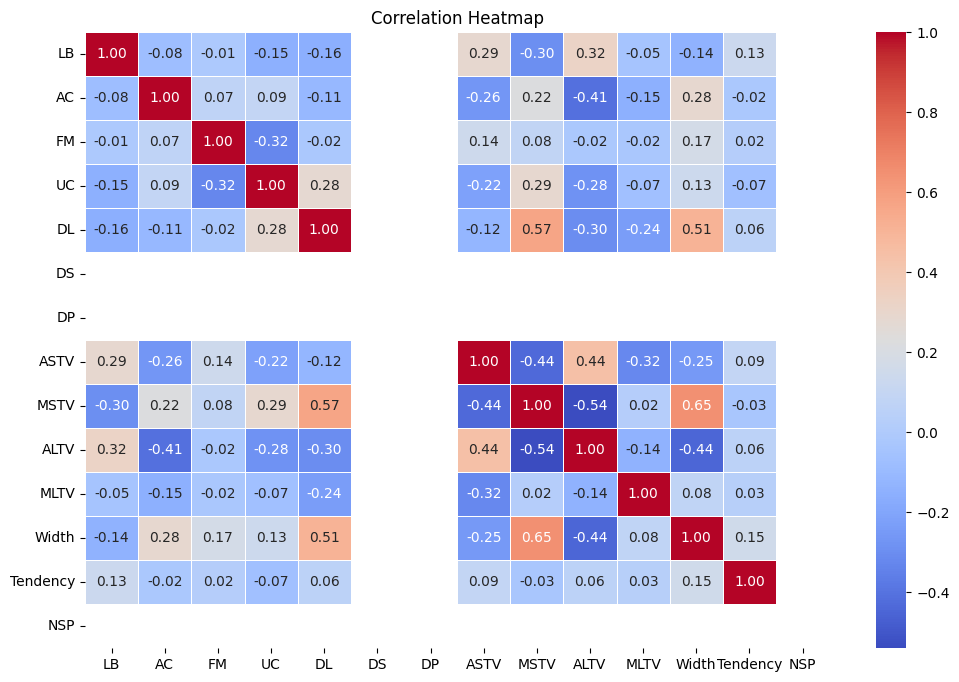

In [21]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


**Correlation Insights:**

---


1.LB (Baseline FHR) has a weak correlation with most
features.

2.ASTV and ALTV show a strong positive correlation, suggesting a relationship in fetal variability patterns.

3.MSTV and MLTV are also highly correlated, indicating they measure similar aspects of variability.

4.Width and Tendency have some correlation, which may indicate a dependency in contraction patterns.





Here’s a * report** summarizing the exploratory data analysis (EDA) of the **Cardiotocographic** dataset.  

---

# **Exploratory Data Analysis Report**
## **Objective**
The goal of this analysis was to explore and understand the structure of the **Cardiotocographic** dataset, identify patterns, and uncover insights through data cleaning, statistical summaries, and visualizations.

## **Data Cleaning & Preparation**
1. **Handling Missing Values:**  
   - Missing values were detected in multiple columns.
   - Imputed missing values using the **median** to maintain data consistency.

2. **Negative Values:**  
   - Several columns contained negative values, which were corrected by taking their absolute values.

3. **Outlier Treatment:**  
   - Extreme values were identified using the **Interquartile Range (IQR) method**.
   - Outliers were capped at 1.5 times the IQR to prevent skewed distributions.

## **Statistical Summary**
- The dataset contained **14 numerical variables** related to fetal heart rate patterns.
- Measures of **central tendency** (mean, median) and **dispersion** (standard deviation, IQR) were computed.
- Key findings:
  - **High variability** was observed in features related to fetal movement and variability.
  - Some columns had **extreme values**, which required outlier treatment.

## **Data Visualization**
1. **Boxplots:**  
   - Revealed the presence of outliers, especially in **LB, MLTV, ALTV, ASTV, Width**, and **NSP**.  
   - After treatment, distributions appeared more balanced.  

2. **Correlation Heatmap:**  
   - **Strong correlations** were observed between:
     - **ASTV & ALTV** (short and long-term variability)
     - **MSTV & MLTV** (mean short-term and long-term variability)
   - Some features showed weak or no correlation with others.

## **Key Insights**
- **Fetal heart rate (LB)** does not strongly correlate with most features, suggesting independent variability.
- **Variability metrics (ASTV, ALTV, MSTV, MLTV)** are highly interrelated, indicating they may measure similar aspects of fetal heart health.
- The **Width** and **Tendency** features had a moderate correlation, which may indicate a dependency in contraction patterns.

## **Conclusion**
- The dataset was cleaned and preprocessed for further analysis.
- Outliers were successfully handled to improve data quality.
- Key patterns and correlations were identified, which could be used for **predictive modeling or classification** in fetal health monitoring.